# Meteocat Radar Tile Explorer

Interactively play with x, y values and download Meteocat radar images, visualize individual tiles, and stitch them.

In [11]:
# 1. Import Required Libraries
import os
import cv2
import numpy as np
import requests
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
import matplotlib.pyplot as plt
import ipywidgets as widgets
from loguru import logger
display = __import__('IPython.display').display

## 2. Configure Radar Tile Parameters
Set up parameters such as timestamp, zoom, tile size, and allow user input for x and y values.

In [5]:
# Set up parameters
ZOOM = 7  # Meteocat radar zoom level (7 or 8)
TILE_SIZE = 1024  # px (for radar tiles at zoom 7)

# Default timestamp: 5 minutes ago in Europe/Madrid
RADAR_TIMESTAMP = datetime.now(ZoneInfo("Europe/Madrid")) - timedelta(minutes=5)

# Default x and y ranges for Catalonia (adjust as needed)
default_x_range = [64, 65]
default_y = 80

# Widgets for user input
x_widget = widgets.IntSlider(value=default_x_range[0], min=60, max=70, step=1, description='x')
y_widget = widgets.IntSlider(value=default_y, min=75, max=85, step=1, description='y')
timestamp_widget = widgets.Text(value=RADAR_TIMESTAMP.strftime('%Y-%m-%d %H:%M'), description='Timestamp (local)', placeholder='YYYY-MM-DD HH:MM')
from IPython.display import display as ipy_display
ipy_display(x_widget, y_widget, timestamp_widget)

IntSlider(value=64, description='x', max=70, min=60)

IntSlider(value=80, description='y', max=85, min=75)

Text(value='2026-05-18 12:37', description='Timestamp (local)', placeholder='YYYY-MM-DD HH:MM')

## 3. Generate Tile URLs
Define functions to generate the Meteocat radar tile URL and the map (background) tile URL for given parameters.

- `get_tile_url(dt, zoom, x, y)`: Returns the radar tile URL for a given datetime, zoom, x, and y.
- `get_map_tile_url(zoom, x, y)`: Returns the map tile URL for a given zoom, x, and y.

In [9]:
def get_tile_url(dt, zoom, x, y):
    """Generate Meteocat radar tile URL for given datetime, zoom, x, y."""
    return (
        f"https://static-m.meteo.cat/tiles/radar/"
        f"{dt.year:04d}/{dt.month:02d}/{dt.day:02d}/"
        f"{dt.hour:02d}/{dt.minute:02d}/07/000/000/"
        f"{x:03d}/000/000/{y:03d}.png"
    )

def get_map_tile_url(zoom, x, y):
    """
    Generate Meteocat map tile URL for given zoom, x, y.
    """
    return (
        f"https://static-m.meteo.cat/tiles/fons/GoogleMapsCompatible/"
        f"{zoom:02d}/000/000/{x:03d}/000/000/{y:03d}.png"
    )

## 4. Download Radar and Map Tiles
Define functions to download a radar or map tile and return it as a numpy array.

- `download_tile(url)`: Downloads a radar tile from a URL and returns it as a numpy array.
- `download_map_tile(zoom, x, y, out_path=None)`: Downloads a map tile for the given zoom, x, y. If `out_path` is provided, saves the image to file. Always returns the image as a numpy array (or None if download fails).

In [ ]:
def download_tile(url):
    """Download a single tile image from URL and return as numpy array."""
    resp = requests.get(url)
    if resp.status_code == 200:
        arr = np.asarray(bytearray(resp.content), dtype=np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_UNCHANGED)
        return img
    else:
        logger.error(f"Failed to download {url}")
        return None

In [10]:

def download_map_tile(zoom, x, y, out_path=None):
    """
    Download a Meteocat map tile for the given zoom, x, y and save to out_path.
    If out_path is None, use 'map_tile_{x}_{y}.png'.
    """
    url = get_map_tile_url(zoom, x, y)
    response = requests.get(url)
    if response.status_code == 200:
        if out_path is None:
            out_path = f"map_tile_{x}_{y}.png"
        with open(out_path, "wb") as f:
            f.write(response.content)
        print(f"Saved map tile to {out_path}")
    else:
        print("Failed to download map tile")

In [29]:
def get_numpy_map_tile(zoom, x, y, out_path=None):
    """
    Get a Meteocat map tile as a numpy array for the given zoom, x, y.
    If out_path is provided, save to file. Always return the image as a numpy array (or None if failed).
    """
    url = get_map_tile_url(zoom, x, y)
    response = requests.get(url)
    if response.status_code == 200:
        arr = np.asarray(bytearray(response.content), dtype=np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        if out_path is None:
            if out_path is not False:
                out_path = f"map_tile_{x}_{y}.png"
                with open(out_path, "wb") as f:
                    f.write(response.content)
            logger.success(f"Saved map tile to {out_path}")
        return img
    else:
        logger.error(f"Failed to download map tile {url=}")
        return None

## 5. Check images, zoom and coordinates
Download and display individual radar tiles for selected x and y values using matplotlib.

In [24]:
# Set up parameters
ZOOM = 7  # Meteocat radar zoom level (7 or 8)
TILE_SIZE = 1024  # px (for radar tiles at zoom 7)

# Default timestamp: 5 minutes ago in Europe/Madrid
RADAR_TIMESTAMP = datetime.now(ZoneInfo("Europe/Madrid")) - timedelta(minutes=5)

# Default x and y ranges for Catalonia (adjust as needed)
default_x_range = [64, 65]
default_y = 80

# Widgets for user input
zoom_widget = widgets.IntSlider(value=default_x_range[0], min=7, max=8, step=1, description='zoom')
x_widget = widgets.IntSlider(value=default_x_range[0], min=60, max=70, step=1, description='x')
y_widget = widgets.IntSlider(value=default_y, min=75, max=85, step=1, description='y')
timestamp_widget = widgets.Text(value=RADAR_TIMESTAMP.strftime('%Y-%m-%d %H:%M'), description='Timestamp (local)', placeholder='YYYY-MM-DD HH:MM')
from IPython.display import display as ipy_display
ipy_display(zoom_widget, x_widget, y_widget, timestamp_widget)
map_image= get_numpy_map_tile(zoom_widget.value, x_widget.value, y_widget.value, out_path=False)
ipy_display(map_image)

IntSlider(value=8, description='zoom', max=8, min=7)

IntSlider(value=64, description='x', max=70, min=60)

IntSlider(value=80, description='y', max=85, min=75)

Text(value='2026-05-18 13:41', description='Timestamp (local)', placeholder='YYYY-MM-DD HH:MM')

2026-05-18 13:46:03.666 | ERROR    | __main__:get_numpy_map_tile:19 - Failed to download map tile url='https://static-m.meteo.cat/tiles/fons/GoogleMapsCompatible/08/000/000/064/000/000/080.png'


None

In [ ]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display as ipy_display

def show_map_image(zoom, x, y):
    img = get_numpy_map_tile(zoom, x, y, out_path=False)
    if img is not None:
        plt.figure(figsize=(10,20))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    else:
        print("No image to display")

zoom_widget = widgets.IntSlider(value=7, min=7, max=8, step=1, description='zoom')
x_widget = widgets.IntSlider(value=64, min=63, max=65, step=0.1, description='x')
y_widget = widgets.IntSlider(value=80, min=75, max=85, step=1, description='y')

ui = widgets.HBox([zoom_widget, x_widget, y_widget])
out = widgets.interactive_output(show_map_image, {'zoom': zoom_widget, 'x': x_widget, 'y': y_widget})

ipy_display(ui, out)

Output()

In [16]:
x_widget.value

64

zoom 0 

<img class="leaflet-tile leaflet-tile-loaded" style="height: 256px; width: 256px; transform: translate3d(531px, 216px, 0px);" src="https://static-m.meteo.cat/tiles/fons/GoogleMapsCompatible/08/000/000/129/000/000/160.png" alt="">

zoom -1

<img class="leaflet-tile leaflet-tile-loaded" style="height: 256px; width: 256px; transform: translate3d(490px, 151px, 0px);" src="https://static-m.meteo.cat/tiles/fons/GoogleMapsCompatible/07/000/000/064/000/000/080.png" alt="">

zoom 1
<img class="leaflet-tile leaflet-tile-loaded" style="height: 256px; width: 256px; transform: translate3d(412px, 80px, 0px);" src="https://static-m.meteo.cat/tiles/fons/GoogleMapsCompatible/09/000/000/258/000/000/321.png" alt="">

zoom 2 

<img class="leaflet-tile leaflet-tile-loaded" style="height: 256px; width: 256px; transform: translate3d(508px, 154px, 0px);" src="https://static-m.meteo.cat/tiles/fons/GoogleMapsCompatible/10/000/000/517/000/000/642.png" alt="">

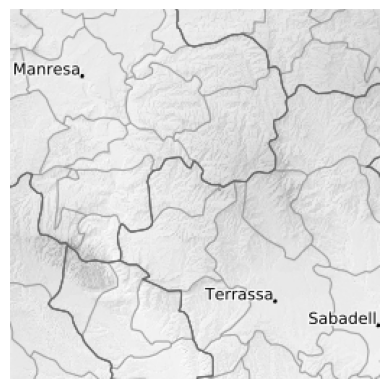

In [ ]:
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt
<img class="leaflet-tile leaflet-tile-loaded" style="height: 256px; width: 256px; transform: translate3d(691px, 137px, 0px);" src="https://static-m.meteo.cat/tiles/fons/GoogleMapsCompatible/10/000/000/518/000/000/642.png" alt="">
url = "https://static-m.meteo.cat/tiles/fons/GoogleMapsCompatible/10/000/000/517/000/000/642.png"
response = requests.get(url)
if response.status_code == 200:
    arr = np.asarray(bytearray(response.content), dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
else:
    print("Failed to download image")